In [5]:
import json
import os

kaggle_creds = {
    "username": "vidushisharma1011",
    "key": "KGAT_8ff113537964c4de942056d2b69ed6de"
}

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_creds, f)


In [6]:
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d ambarish/breakhis
!unzip breakhis.zip

In [8]:
import os
import shutil
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import Subset
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [9]:
img_size = 256
batch_size = 32
num_classes = 8
learning_rate = 1e-4
epochs = 50

In [10]:
src_root = "BreaKHis_v1/BreaKHis_v1/histology_slides/breast"
dst_root = "breakhis_multiclass"

os.makedirs(dst_root, exist_ok=True)

In [11]:
for group in ["benign", "malignant"]:
    group_path = os.path.join(src_root, group, "SOB")

    for cls in os.listdir(group_path):
        cls_path = os.path.join(group_path, cls)

        # one folder per class (8 total)
        dst_cls = os.path.join(dst_root, cls)
        os.makedirs(dst_cls, exist_ok=True)

        for case in os.listdir(cls_path):
            case_path = os.path.join(cls_path, case)

            for mag in os.listdir(case_path):
                if mag != "40X":
                    continue

                mag_path = os.path.join(case_path, mag)

                for img in os.listdir(mag_path):
                    if img.lower().endswith((".png", ".jpg", ".jpeg")):
                        new_name = f"{cls}_{case}_{img}"

                        shutil.copy(
                            os.path.join(mag_path, img),
                            os.path.join(dst_cls, new_name)
                        )

print("40X dataset for all 8 classes created successfully!")


40X dataset for all 8 classes created successfully!


In [12]:
import random
from sklearn.model_selection import train_test_split

# paths
src_root = "breakhis_multiclass"
dst_root = "breakhis_split"

splits = ["train", "val", "test"]
ratios = [0.6, 0.1, 0.3]

random.seed(42)

# create base directories
for split in splits:
    os.makedirs(os.path.join(dst_root, split), exist_ok=True)

# loop over classes
for cls in os.listdir(src_root):
    cls_path = os.path.join(src_root, cls)
    if not os.path.isdir(cls_path):
        continue

    images = os.listdir(cls_path)
    random.shuffle(images)

    # split indices
    train_imgs, temp_imgs = train_test_split(
        images, test_size=0.4, random_state=42
    )
    val_imgs, test_imgs = train_test_split(
        temp_imgs, test_size=0.75, random_state=42
    )

    split_map = {
        "train": train_imgs,
        "val": val_imgs,
        "test": test_imgs
    }

    # copy files
    for split, split_imgs in split_map.items():
        split_cls_dir = os.path.join(dst_root, split, cls)
        os.makedirs(split_cls_dir, exist_ok=True)

        for img in split_imgs:
            shutil.copy(
                os.path.join(cls_path, img),
                os.path.join(split_cls_dir, img)
            )

    print(f"{cls}: train={len(train_imgs)}, val={len(val_imgs)}, test={len(test_imgs)}")

print("Dataset split completed successfully!")

papillary_carcinoma: train=87, val=14, test=44
tubular_adenoma: train=89, val=15, test=45
lobular_carcinoma: train=93, val=15, test=48
fibroadenoma: train=151, val=25, test=77
mucinous_carcinoma: train=123, val=20, test=62
ductal_carcinoma: train=518, val=86, test=260
adenosis: train=68, val=11, test=35
phyllodes_tumor: train=65, val=11, test=33
Dataset split completed successfully!


In [13]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [14]:
train_dir = "/content/breakhis_split/train"
val_dir   = "/content/breakhis_split/val"
test_dir  = "/content/breakhis_split/test"

In [15]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_test_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=val_test_transform)

In [16]:
print(train_dataset.classes)

['adenosis', 'ductal_carcinoma', 'fibroadenoma', 'lobular_carcinoma', 'mucinous_carcinoma', 'papillary_carcinoma', 'phyllodes_tumor', 'tubular_adenoma']


In [17]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders ready.")

DataLoaders ready.


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 8
num_epochs = 10
learning_rate = 1e-4

In [19]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 203MB/s]


In [20]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [21]:
for epoch in range(num_epochs):

    # TRAIN
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = 100.0 * train_correct / train_total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = 100.0 * val_correct / val_total

    print(f"Epoch [{epoch+1:02d}/{num_epochs}] | "
          f"Train Acc: {train_acc:.2f}% || Val Acc: {val_acc:.2f}%")

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

print("Training complete.")

Epoch [01/10] | Train Acc: 58.88% || Val Acc: 72.08%
Epoch [02/10] | Train Acc: 84.67% || Val Acc: 82.74%
Epoch [03/10] | Train Acc: 91.37% || Val Acc: 86.80%
Epoch [04/10] | Train Acc: 94.30% || Val Acc: 88.83%
Epoch [05/10] | Train Acc: 94.72% || Val Acc: 87.31%
Epoch [06/10] | Train Acc: 96.65% || Val Acc: 85.79%
Epoch [07/10] | Train Acc: 96.06% || Val Acc: 88.83%
Epoch [08/10] | Train Acc: 95.81% || Val Acc: 91.37%
Epoch [09/10] | Train Acc: 97.07% || Val Acc: 89.34%
Epoch [10/10] | Train Acc: 97.07% || Val Acc: 89.34%
Training complete.


In [22]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

acc  = accuracy_score(y_true, y_pred) * 100
prec = precision_score(y_true, y_pred, average="macro") * 100
rec  = recall_score(y_true, y_pred, average="macro") * 100
f1   = f1_score(y_true, y_pred, average="macro") * 100

print("\nSOFTMAX TEST METRICS")
print(f"Accuracy : {acc:.2f}%")
print(f"Precision: {prec:.2f}%")
print(f"Recall   : {rec:.2f}%")
print(f"F1-score : {f1:.2f}%")


SOFTMAX TEST METRICS
Accuracy : 92.72%
Precision: 92.74%
Recall   : 89.62%
F1-score : 90.93%


In [23]:
feature_extractor = nn.Sequential(*list(model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [24]:
def extract_features(loader):
    features = []
    labels = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)

            feats = feature_extractor(images)
            feats = feats.view(feats.size(0), -1)

            features.append(feats.cpu().numpy())
            labels.append(targets.numpy())

    return np.vstack(features), np.concatenate(labels)

print("Extracting training features...")
X_train, y_train = extract_features(train_loader)

print("Extracting test features...")
X_test, y_test = extract_features(test_loader)

print("Feature shape:", X_train.shape)

Extracting training features...
Extracting test features...
Feature shape: (1194, 512)


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=10, gamma='scale')

print("Training SVM...")
svm.fit(X_train, y_train)

print("SVM training complete.")

Training SVM...
SVM training complete.


In [27]:
y_pred_svm = svm.predict(X_test)

acc  = accuracy_score(y_test, y_pred_svm) * 100
prec = precision_score(y_test, y_pred_svm, average="macro") * 100
rec  = recall_score(y_test, y_pred_svm, average="macro") * 100
f1   = f1_score(y_test, y_pred_svm, average="macro") * 100

print("\nSVM TEST METRICS")
print(f"Accuracy : {acc:.2f}%")
print(f"Precision: {prec:.2f}%")
print(f"Recall   : {rec:.2f}%")
print(f"F1-score : {f1:.2f}%")


SVM TEST METRICS
Accuracy : 94.54%
Precision: 94.83%
Recall   : 92.53%
F1-score : 93.61%


In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        35
           1       0.94      0.98      0.96       260
           2       0.99      0.94      0.96        77
           3       0.86      0.79      0.83        48
           4       0.95      0.98      0.97        62
           5       0.98      0.91      0.94        44
           6       0.94      0.88      0.91        33
           7       0.93      0.96      0.95        45

    accuracy                           0.95       604
   macro avg       0.95      0.93      0.94       604
weighted avg       0.95      0.95      0.94       604



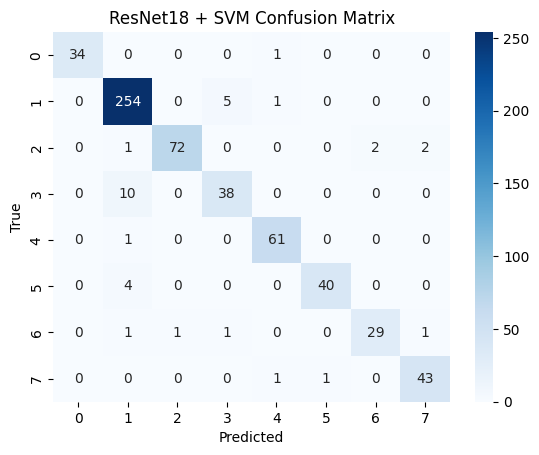

In [30]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ResNet18 + SVM Confusion Matrix")
plt.show()